In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('housingData.csv')
df

,house_area,house_price,bedrooms,lift,city,floor
0,1262.881245,38.156437,3bhk,NaN,Hyd,third
1,1143.840962,35.415229,2bhk,0.0,Mumbai,ground
2,1362.809667,42.734290,3bhk,0.0,Mumbai,ground
3,1215.430502,38.252915,2bhk,NaN,Mumbai,first
4,1078.882497,33.886475,1bhk,0.0,Blr,ground
...,...,...,...,...,...,...
995,1019.644332,32.719330,1bhk,NaN,Pune,second
996,1153.063719,34.981912,NaN,NaN,Pune,second
997,1255.712846,38.081385,3bhk,NaN,Pune,first
998,1240.645962,39.179379,3bhk,NaN,Hyd,second


In [3]:
data=df.copy()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   house_area   998 non-null    float64
 1   house_price  996 non-null    float64
 2   bedrooms     888 non-null    object 
 3   lift         665 non-null    float64
 4   city         1000 non-null   object 
 5   floor        1000 non-null   object 
dtypes: float64(3), object(3)
memory usage: 47.0+ KB


In [4]:
## Basic Univariate analysis
data.describe()

,house_area,house_price,lift
count,998.000000,996.000000,665.000000
mean,1199.326476,37.464903,0.530827
std,102.273826,3.535658,0.499424
min,904.610767,27.890655,0.000000
25%,1128.958684,35.057734,0.000000
50%,1199.572876,37.183527,1.000000
75%,1267.210042,39.529560,1.000000
max,1525.378160,48.071345,1.000000


In [5]:
data.describe(include=['object'])

,bedrooms,city,floor
count,888,1000,1000
unique,3,4,4
top,2bhk,Pune,third
freq,380,346,340


In [6]:
## count of null
data.isna().sum()

,0
house_area,2
house_price,4
bedrooms,112
lift,335
city,0
floor,0


In [7]:
data.isna().sum()/len(data)

,0
house_area,0.002
house_price,0.004
bedrooms,0.112
lift,0.335
city,0.000
floor,0.000


In [8]:
## We need to handle these null values first

# 1. Null values for house_area and house_price are very less in numbers
# - we can do data pruning, drop these rows

data = data.dropna(subset=['house_area','house_price'])
data

,house_area,house_price,bedrooms,lift,city,floor
0,1262.881245,38.156437,3bhk,NaN,Hyd,third
1,1143.840962,35.415229,2bhk,0.0,Mumbai,ground
2,1362.809667,42.734290,3bhk,0.0,Mumbai,ground
3,1215.430502,38.252915,2bhk,NaN,Mumbai,first
4,1078.882497,33.886475,1bhk,0.0,Blr,ground
...,...,...,...,...,...,...
995,1019.644332,32.719330,1bhk,NaN,Pune,second
996,1153.063719,34.981912,NaN,NaN,Pune,second
997,1255.712846,38.081385,3bhk,NaN,Pune,first
998,1240.645962,39.179379,3bhk,NaN,Hyd,second


In [9]:
# bedrooms column has 11% null values
# lets try data imputation using some approximation
# We know that bedrooms can be highly correlated with house_area
# Lets try to find an assumption for bedrooms using house_area

In [10]:
temp = data.dropna(subset=['bedrooms'])
temp

,house_area,house_price,bedrooms,lift,city,floor
0,1262.881245,38.156437,3bhk,NaN,Hyd,third
1,1143.840962,35.415229,2bhk,0.0,Mumbai,ground
2,1362.809667,42.734290,3bhk,0.0,Mumbai,ground
3,1215.430502,38.252915,2bhk,NaN,Mumbai,first
4,1078.882497,33.886475,1bhk,0.0,Blr,ground
...,...,...,...,...,...,...
994,1179.215745,37.676472,2bhk,NaN,Pune,ground
995,1019.644332,32.719330,1bhk,NaN,Pune,second
997,1255.712846,38.081385,3bhk,NaN,Pune,first
998,1240.645962,39.179379,3bhk,NaN,Hyd,second


In [13]:
# Bivarate analysis of house_area and bedrooms is needed
def cont_cat_bivar(data,cont_col,cat_col):
  #non-visual
  metrics = data.groupby(cat_col)[cont_col].agg(['mean','median','min','max'])
  print(metrics)
  #visual
  # sns.kdeplot(x=cont_col,data=data,hue=cat_col)
  sns.boxplot(x=cat_col,y=cont_col,data=data)
  plt.show()

                 mean       median          min          max
bedrooms                                                    
1bhk      1059.212408  1071.193733   904.610767  1117.147794
2bhk      1181.314806  1184.119820  1118.053385  1235.860711
3bhk      1308.774416  1294.806085  1235.883620  1525.378160


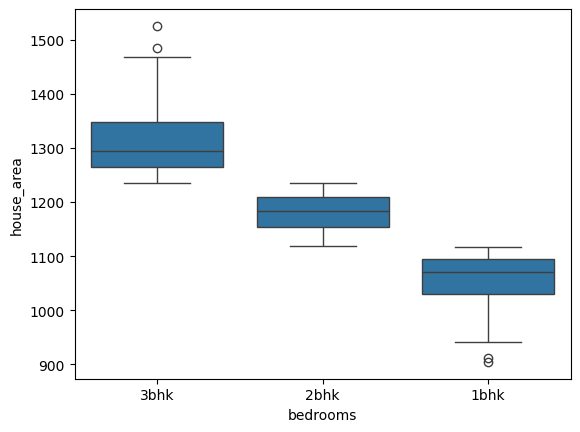

In [14]:
cont_cat_bivar(temp,'house_area','bedrooms')

In [17]:
# Looking at the bivariate analysis, its clear that house_area and bedrooms have a strong relationship
# We can use this relationship to approximate the missing bedroom values


# assumption
# if area <=1100 -> 1bhk
# if 1100 < area <=1220 -> 2bhk
# if 1220 < area -> 3bhk

# Use this assumption for data imputation

In [26]:
def area_to_bedrooms(area):
  if area<=1100:
    return '1bhk'
  elif area<=1220 and area>1100:
    return '2bhk'
  else:
    return '3bhk'

In [27]:
null_bedroom_df = data[data['bedrooms'].isna()]
null_bedroom_df['bedrooms'] = null_bedroom_df['house_area'].apply(area_to_bedrooms)
null_bedroom_df

/tmp/ipykernel_6659/1420089461.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  null_bedroom_df['bedrooms'] = null_bedroom_df['house_area'].apply(area_to_bedrooms)


,house_area,house_price,bedrooms,lift,city,floor
6,1201.155608,37.184668,2bhk,0.0,Mumbai,ground
15,1184.647009,35.909410,2bhk,1.0,Hyd,second
22,1238.824756,40.504743,3bhk,0.0,Pune,third
46,986.217155,30.306515,1bhk,1.0,Hyd,third
68,1256.945302,38.058359,3bhk,1.0,Pune,second
...,...,...,...,...,...,...
972,1248.220737,39.096622,3bhk,1.0,Hyd,third
975,1160.262432,35.427873,2bhk,0.0,Pune,third
986,1115.932302,34.337969,2bhk,1.0,Pune,second
993,992.807663,30.694230,1bhk,1.0,Pune,third


In [29]:
non_null_bedroom_df = data[data.bedrooms.notna()]
non_null_bedroom_df

,house_area,house_price,bedrooms,lift,city,floor
0,1262.881245,38.156437,3bhk,NaN,Hyd,third
1,1143.840962,35.415229,2bhk,0.0,Mumbai,ground
2,1362.809667,42.734290,3bhk,0.0,Mumbai,ground
3,1215.430502,38.252915,2bhk,NaN,Mumbai,first
4,1078.882497,33.886475,1bhk,0.0,Blr,ground
...,...,...,...,...,...,...
994,1179.215745,37.676472,2bhk,NaN,Pune,ground
995,1019.644332,32.719330,1bhk,NaN,Pune,second
997,1255.712846,38.081385,3bhk,NaN,Pune,first
998,1240.645962,39.179379,3bhk,NaN,Hyd,second


In [30]:
new_data = pd.concat([null_bedroom_df,non_null_bedroom_df])
new_data

,house_area,house_price,bedrooms,lift,city,floor
6,1201.155608,37.184668,2bhk,0.0,Mumbai,ground
15,1184.647009,35.909410,2bhk,1.0,Hyd,second
22,1238.824756,40.504743,3bhk,0.0,Pune,third
46,986.217155,30.306515,1bhk,1.0,Hyd,third
68,1256.945302,38.058359,3bhk,1.0,Pune,second
...,...,...,...,...,...,...
994,1179.215745,37.676472,2bhk,NaN,Pune,ground
995,1019.644332,32.719330,1bhk,NaN,Pune,second
997,1255.712846,38.081385,3bhk,NaN,Pune,first
998,1240.645962,39.179379,3bhk,NaN,Hyd,second


In [32]:
new_data.isna().sum()/len(new_data)

,0
house_area,0.000000
house_price,0.000000
bedrooms,0.000000
lift,0.334004
city,0.000000
floor,0.000000


In [ ]:
# for lift null values are 33 % of all data
# - as this number is huge, its better to drop this column

In [34]:
data = new_data.drop('lift',axis=1)
data

,house_area,house_price,bedrooms,city,floor
6,1201.155608,37.184668,2bhk,Mumbai,ground
15,1184.647009,35.909410,2bhk,Hyd,second
22,1238.824756,40.504743,3bhk,Pune,third
46,986.217155,30.306515,1bhk,Hyd,third
68,1256.945302,38.058359,3bhk,Pune,second
...,...,...,...,...,...
994,1179.215745,37.676472,2bhk,Pune,ground
995,1019.644332,32.719330,1bhk,Pune,second
997,1255.712846,38.081385,3bhk,Pune,first
998,1240.645962,39.179379,3bhk,Hyd,second


In [35]:
data.isna().sum()

,0
house_area,0
house_price,0
bedrooms,0
city,0
floor,0


## Outlier handling
- Detect outliers, handle them

In [36]:
data

,house_area,house_price,bedrooms,city,floor
6,1201.155608,37.184668,2bhk,Mumbai,ground
15,1184.647009,35.909410,2bhk,Hyd,second
22,1238.824756,40.504743,3bhk,Pune,third
46,986.217155,30.306515,1bhk,Hyd,third
68,1256.945302,38.058359,3bhk,Pune,second
...,...,...,...,...,...
994,1179.215745,37.676472,2bhk,Pune,ground
995,1019.644332,32.719330,1bhk,Pune,second
997,1255.712846,38.081385,3bhk,Pune,first
998,1240.645962,39.179379,3bhk,Hyd,second


In [37]:
def cont_univar_analysis(data,col):
  ## non-visual analysis
  series = data[col]
  metrics = series.agg(['count','min','max','mean','median','var','std','skew','kurt']).round(2)
  print("Continuous Data Metrics")
  print(metrics)

  # visual analysis
  sns.histplot(data[col],bins=20,kde=True)
  plt.show()
  sns.boxplot(data[col])
  plt.show()


Continuous Data Metrics
count       994.00
min         904.61
max        1525.38
mean       1199.58
median     1199.79
var       10462.00
std         102.28
skew          0.06
kurt         -0.12
Name: house_area, dtype: float64


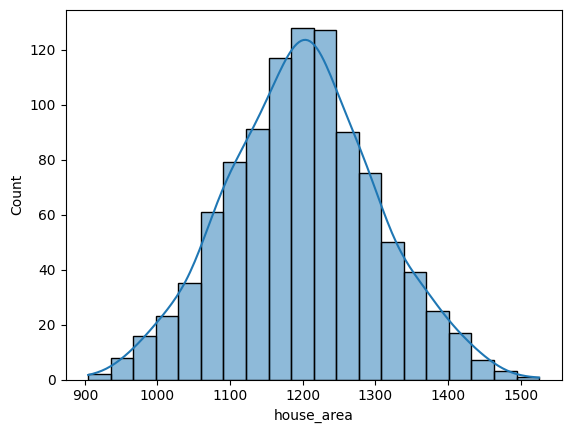

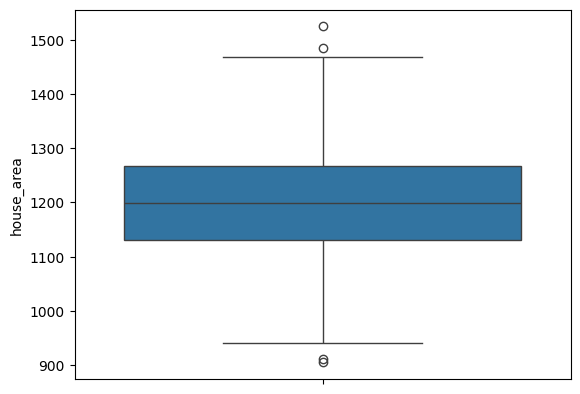

In [38]:
cont_univar_analysis(data,'house_area')

In [39]:
# for house area, outliers are very few and not that extreme hence we can keep them in data

Continuous Data Metrics
count     994.00
min        27.89
max        48.07
mean       37.46
median     37.18
var        12.51
std         3.54
skew        0.27
kurt       -0.15
Name: house_price, dtype: float64


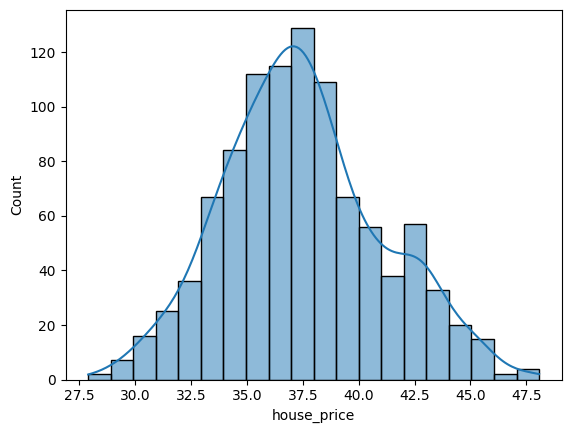

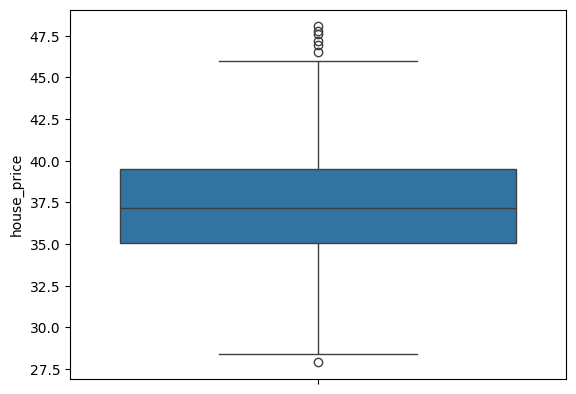

In [40]:
cont_univar_analysis(data,'house_price')

In [44]:
## we can remove outliers in price as they are good in numbers
# based on iqr limits
# upper limit = q3 + 1.5*iqr
# lower limit = q1 - 1.5*iqr

q1 = data['house_price'].quantile(0.25)
q3 = data['house_price'].quantile(0.75)
iqr = q3-q1
print("iqr=",iqr)
ul = q3 + 1.5*iqr
ll = q1 - 1.5*iqr
print('UL = ',ul)
print('LL = ',ll)

iqr= 4.466782629975974
UL =  46.22345134108595
LL =  28.35632082118205


In [45]:
## remove outliers based on above UL and LL

data = data[(data['house_price']>=ll) & (data['house_price']<=ul)]
data

,house_area,house_price,bedrooms,city,floor
6,1201.155608,37.184668,2bhk,Mumbai,ground
15,1184.647009,35.909410,2bhk,Hyd,second
22,1238.824756,40.504743,3bhk,Pune,third
46,986.217155,30.306515,1bhk,Hyd,third
68,1256.945302,38.058359,3bhk,Pune,second
...,...,...,...,...,...
994,1179.215745,37.676472,2bhk,Pune,ground
995,1019.644332,32.719330,1bhk,Pune,second
997,1255.712846,38.081385,3bhk,Pune,first
998,1240.645962,39.179379,3bhk,Hyd,second


Continuous Data Metrics
count     987.00
min        28.38
max        45.98
mean       37.41
median     37.16
var        11.91
std         3.45
skew        0.22
kurt       -0.30
Name: house_price, dtype: float64


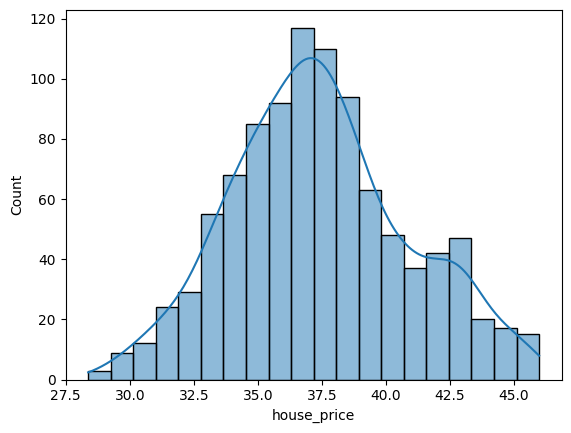

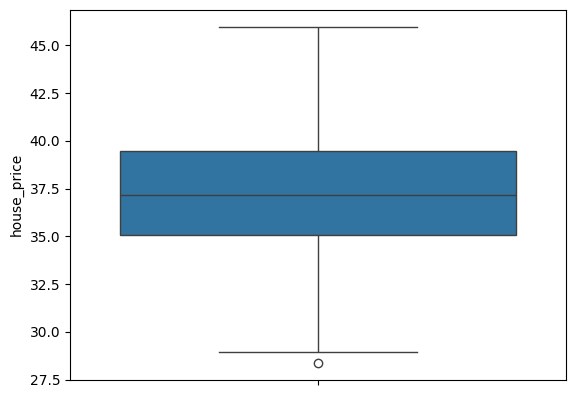

In [46]:
cont_univar_analysis(data,'house_price')

In [47]:
## almost all of the outliers in price are removed